# A/B Testing Project

## Teaching Businesses to Make Decisions With Evidence Instead of Opinions

GraphX Labs ML Concepts Portfolio

> What if we could scientifically test whether a business decision actually works?

This notebook is not a formula tour. It is the story of a product team trying to decide whether a new checkout experience deserves to be launched.

The business sees a better button. The data sees uncertainty. A/B testing is how we make the two talk to each other.

## 1. Problem Statement

Businesses experiment because product intuition is useful, but incomplete.

A designer may believe a new checkout page feels safer. A marketer may believe a new headline creates urgency. A product manager may believe a new onboarding flow removes friction.

But users behave in the real world, not inside our confidence.

In this project, we test a new ecommerce checkout call-to-action. The question is not simply whether treatment B has a higher conversion rate in this sample. The deeper question is:

> Is the difference strong enough, stable enough, and valuable enough to trust?

## 2. What Is A/B Testing Intuitively?

A/B testing is a fair trial between two versions of reality.

One group sees the current product. That is the control.

Another group sees the new idea. That is the treatment.

Random assignment is the quiet hero. It makes the groups comparable so we can ask whether the treatment caused a meaningful change.

Think of it like a medicine trial, a taste test, or trying two restaurant menus with similar crowds. If the groups are fair and the measurement is clean, the result becomes evidence instead of opinion.

## 3. Why Randomness Makes Experiments Difficult

Randomness is why A/B testing needs statistics.

Even if two versions are identical, one group may convert a little better by luck. Some users arrive ready to buy. Some are distracted. Some are on mobile. Some came from email. Some came from an ad. Some were never going to purchase.

A small conversion-rate gap can be a real signal, or it can be noise wearing a convincing costume.

Statistical significance exists because experiments are noisy enough to fool smart people.

## 4. Dataset Overview

We use a simulated ecommerce checkout experiment so the project is reproducible and business-realistic.

Experiment setup:

- **Control A:** old checkout call-to-action
- **Treatment B:** new secure checkout call-to-action
- **Outcome:** whether the user converted
- **Context fields:** timestamp, device, country, traffic source, revenue

The treatment is simulated with a modest positive effect, not a cartoonishly large jump. That makes the project closer to real product experimentation, where small lifts can become large business outcomes at scale.

## 5. Import Libraries

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_DIR / 'src'
IMAGE_DIR = PROJECT_DIR / 'images'
DATA_DIR = PROJECT_DIR / 'data'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing.data_preprocessing import save_datasets, prepare_ab_test_data
from experimentation.metrics import conversion_summary, calculate_lift, business_impact
from statistical_testing.ab_tests import two_proportion_ztest, conversion_confidence_intervals, difference_confidence_interval
from simulation.experiment_simulation import simulate_repeated_experiments, sample_size_sensitivity

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

## 6. Load Dataset

If the processed dataset is missing, the notebook regenerates it from the same simulation logic used by the source pipeline.

In [2]:
raw_path = DATA_DIR / 'raw' / 'checkout_ab_test_raw.csv'
processed_path = DATA_DIR / 'processed' / 'checkout_ab_test_processed.csv'

if not processed_path.exists():
    df = save_datasets(raw_path, processed_path, n_users=50000, seed=42)
else:
    df = pd.read_csv(processed_path, parse_dates=['timestamp'])

df.head()

,user_id,timestamp,group,variant,device,country,traffic_source,converted,conversion_probability_simulated,revenue,date,day_of_week,is_treatment,converted_bool,revenue_per_user
0,1,2026-03-21 14:05:00,B,new_secure_checkout_cta,tablet,US,search,1,0.1186,128.81,2026-03-21,Saturday,1,True,128.81
1,2,2026-03-25 16:50:00,A,old_checkout_cta,desktop,IN,email,0,0.1765,0.00,2026-03-25,Wednesday,0,False,0.00
2,3,2026-03-17 00:13:00,B,new_secure_checkout_cta,tablet,IN,search,0,0.1212,0.00,2026-03-17,Tuesday,1,False,0.00
3,4,2026-03-12 14:13:00,B,new_secure_checkout_cta,mobile,IN,email,0,0.1310,0.00,2026-03-12,Thursday,1,False,0.00
4,5,2026-03-01 03:06:00,A,old_checkout_cta,mobile,CA,email,0,0.1106,0.00,2026-03-01,Sunday,0,False,0.00


## 7. Initial Data Inspection

Before trusting an experiment result, a data scientist checks whether the experiment itself looks healthy.

We inspect shape, missing values, group balance, and conversion distribution.

In [3]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.isna().sum())

Shape: (50000, 15)


,user_id,timestamp,group,variant,device,country,traffic_source,converted,conversion_probability_simulated,revenue,date,day_of_week,is_treatment,converted_bool,revenue_per_user
0,1,2026-03-21 14:05:00,B,new_secure_checkout_cta,tablet,US,search,1,0.1186,128.81,2026-03-21,Saturday,1,True,128.81
1,2,2026-03-25 16:50:00,A,old_checkout_cta,desktop,IN,email,0,0.1765,0.00,2026-03-25,Wednesday,0,False,0.00
2,3,2026-03-17 00:13:00,B,new_secure_checkout_cta,tablet,IN,search,0,0.1212,0.00,2026-03-17,Tuesday,1,False,0.00
3,4,2026-03-12 14:13:00,B,new_secure_checkout_cta,mobile,IN,email,0,0.1310,0.00,2026-03-12,Thursday,1,False,0.00
4,5,2026-03-01 03:06:00,A,old_checkout_cta,mobile,CA,email,0,0.1106,0.00,2026-03-01,Sunday,0,False,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   user_id                           50000 non-null  int64         
 1   timestamp                         50000 non-null  datetime64[ns]
 2   group                             50000 non-null  object        
 3   variant                           50000 non-null  object        
 4   device                            50000 non-null  object        
 5   country                           50000 non-null  object        
 6   traffic_source                    50000 non-null  object        
 7   converted                         50000 non-null  int64         
 8   conversion_probability_simulated  50000 non-null  float64       
 9   revenue                           50000 non-null  float64       
 10  date                              50000 non-nu

None

user_id                             0
timestamp                           0
group                               0
variant                             0
device                              0
country                             0
traffic_source                      0
converted                           0
conversion_probability_simulated    0
revenue                             0
date                                0
day_of_week                         0
is_treatment                        0
converted_bool                      0
revenue_per_user                    0
dtype: int64

In [4]:
group_balance = df['group'].value_counts().sort_index().rename_axis('group').reset_index(name='users')
group_balance['share'] = group_balance['users'] / group_balance['users'].sum()
display(group_balance)

display(df['converted'].value_counts(normalize=True).rename('share').to_frame())

,group,users,share
0,A,24814,0.49628
1,B,25186,0.50372


,share
0,0.87924
1,0.12076


## 8. Exploratory Data Analysis

EDA for experiments has a slightly different personality than EDA for modeling.

We are not only looking for patterns. We are checking whether the randomized experiment looks believable.

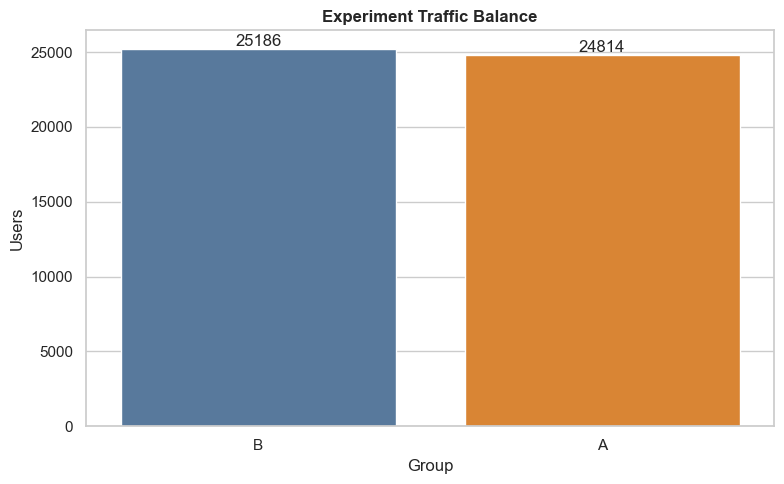

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='group', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_title('Experiment Traffic Balance')
ax.set_xlabel('Group')
ax.set_ylabel('Users')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'group_balance.png', dpi=160, bbox_inches='tight')
plt.show()

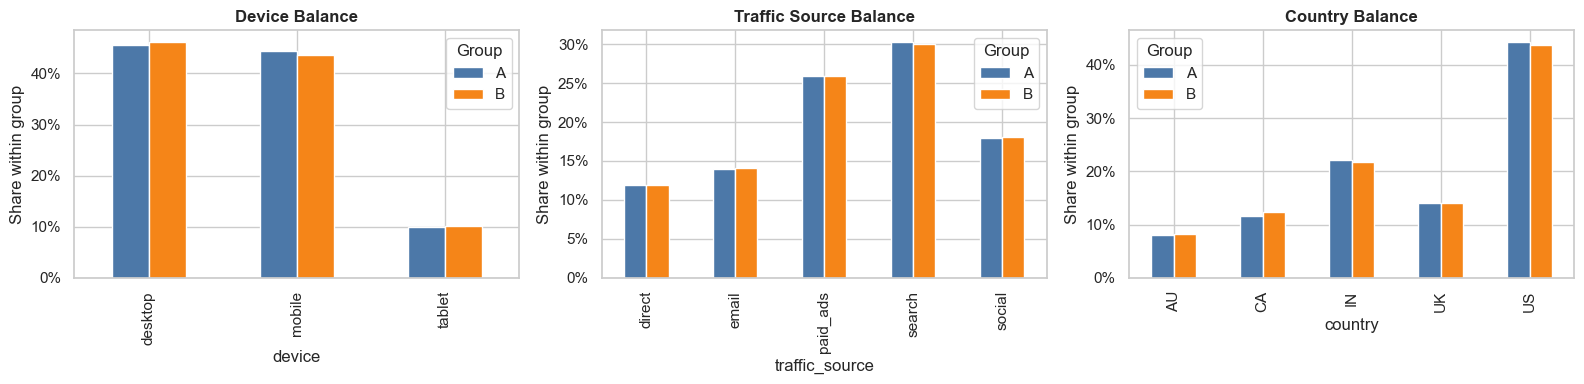

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['device', 'traffic_source', 'country']):
    share = pd.crosstab(df[col], df['group'], normalize='columns')
    share.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518'])
    ax.set_title(f'{col.replace("_", " ").title()} Balance')
    ax.set_ylabel('Share within group')
    ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
    ax.legend(title='Group')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'traffic_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

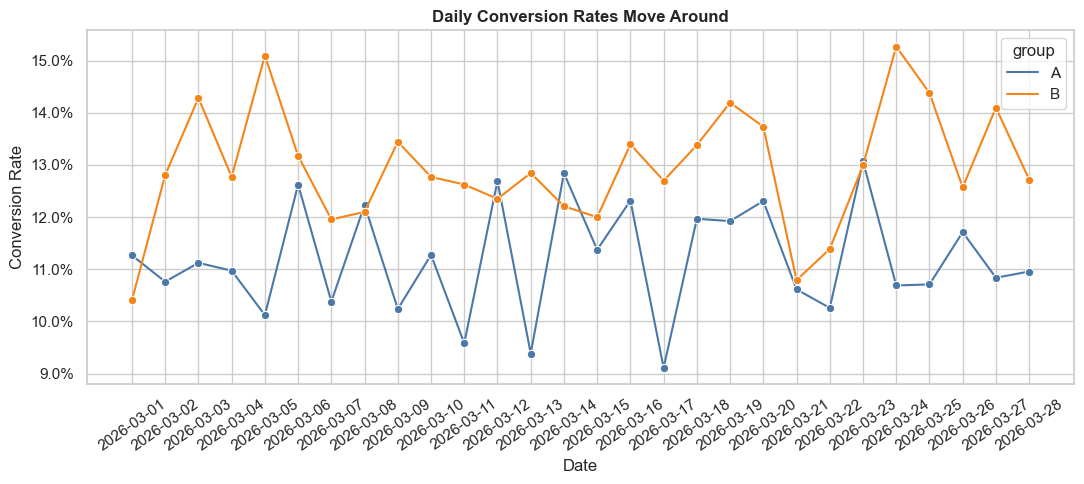

In [7]:
daily = df.groupby(['date', 'group'])['converted'].mean().reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=daily, x='date', y='converted', hue='group', marker='o', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_title('Daily Conversion Rates Move Around')
ax.set_xlabel('Date')
ax.set_ylabel('Conversion Rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'daily_conversion_rates.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Understanding Hypothesis Testing

Hypothesis testing starts with disciplined skepticism.

**Null hypothesis:** the new checkout CTA does not change conversion.

**Alternative hypothesis:** the new checkout CTA changes conversion.

The null is like “innocent until proven guilty.” We do not assume the treatment works just because it looks better. We ask whether the evidence is strong enough to challenge the no-effect explanation.

## 10. Conversion Rates

Conversion rate is the first visible pulse of the experiment.

But it is only the first step. A treatment can have a higher observed conversion rate and still fail to provide enough evidence.

In [8]:
summary = conversion_summary(df)
summary['conversion_rate_pct'] = summary['conversion_rate'] * 100
summary['avg_revenue_per_user'] = summary['avg_revenue_per_user'].round(2)
display(summary)

control_rate = summary.loc[summary['group'] == 'A', 'conversion_rate'].iloc[0]
treatment_rate = summary.loc[summary['group'] == 'B', 'conversion_rate'].iloc[0]
lift = calculate_lift(control_rate, treatment_rate)
print(f"Absolute lift: {lift['absolute_lift']:.3%}")
print(f"Relative lift: {lift['relative_lift']:.2%}")

,group,users,conversions,conversion_rate,total_revenue,avg_revenue_per_user,avg_order_value,conversion_rate_pct
0,A,24814,2776,0.111872,239268.75,9.64,86.191913,11.187233
1,B,25186,3262,0.129516,287201.58,11.40,88.044629,12.951640


Absolute lift: 1.764%
Relative lift: 15.77%


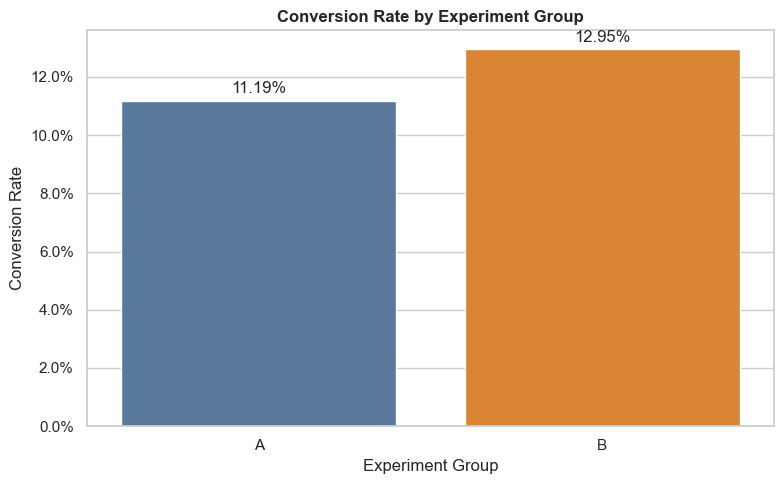

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=summary, x='group', y='conversion_rate', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_title('Conversion Rate by Experiment Group')
ax.set_xlabel('Experiment Group')
ax.set_ylabel('Conversion Rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
for container in ax.containers:
    labels = [f'{v.get_height():.2%}' for v in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'conversion_rates.png', dpi=160, bbox_inches='tight')
plt.show()

## 11. Statistical Significance

A p-value asks:

> If the treatment truly had no effect, how surprising would this observed difference be?

A small p-value means random noise alone is a less convincing explanation. It does not mean the treatment is guaranteed to work forever. It means the observed result has passed a useful evidence threshold.

## 12. Running the A/B Test

Because the outcome is binary, converted or not converted, we use a two-proportion z-test.

In [10]:
test_result = two_proportion_ztest(df)
display(pd.DataFrame([test_result]))

alpha = 0.05
if test_result['p_value'] < alpha:
    print('Result: statistically significant at alpha = 0.05')
else:
    print('Result: not statistically significant at alpha = 0.05')

,control_rate,treatment_rate,z_statistic,p_value,absolute_lift,relative_lift
0,0.111872,0.129516,-6.053777,1.414883e-09,0.017644,0.157716


Result: statistically significant at alpha = 0.05


## 13. Confidence Intervals

A confidence interval keeps the business honest.

Instead of pretending the observed conversion rate is exact, it gives a range of plausible values.

In [11]:
ci_df = conversion_confidence_intervals(df)
diff_ci = difference_confidence_interval(df)
display(ci_df)
display(pd.DataFrame([diff_ci]))

,group,users,conversions,conversion_rate,ci_low,ci_high
0,A,24814,2776,0.111872,0.108010,0.115854
1,B,25186,3262,0.129516,0.125426,0.133720


,difference,standard_error,ci_low,ci_high
0,0.017644,0.002912,0.011936,0.023352


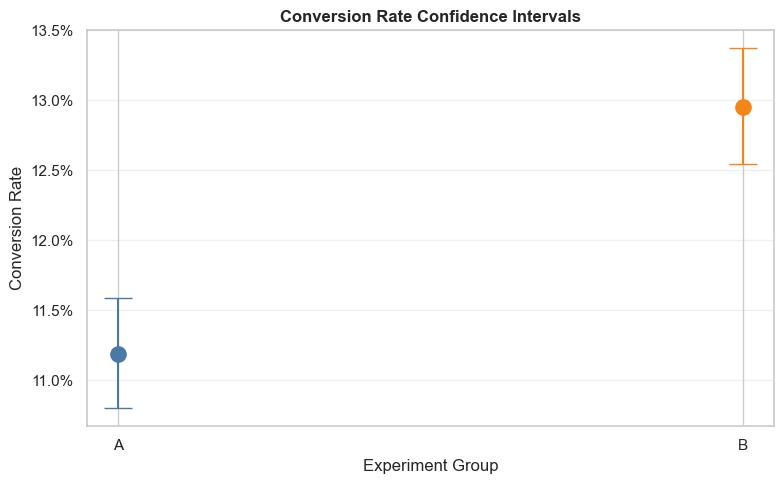

Lift confidence interval: 1.194% to 2.335%


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'A': '#4C78A8', 'B': '#F58518'}
for _, row in ci_df.iterrows():
    ax.errorbar(
        row['group'], row['conversion_rate'],
        yerr=[[row['conversion_rate'] - row['ci_low']], [row['ci_high'] - row['conversion_rate']]],
        fmt='o', capsize=10, markersize=11, color=colors[row['group']], label=f"Group {row['group']}"
    )
ax.set_title('Conversion Rate Confidence Intervals')
ax.set_xlabel('Experiment Group')
ax.set_ylabel('Conversion Rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'confidence_intervals.png', dpi=160, bbox_inches='tight')
plt.show()

print(f"Lift confidence interval: {diff_ci['ci_low']:.3%} to {diff_ci['ci_high']:.3%}")

## 14. Type I and Type II Errors

A/B testing has two classic business mistakes.

**Type I error:** launch a bad feature because random noise made it look good.

**Type II error:** reject a good feature because the experiment was too small or noisy to detect it.

One is a false alarm. The other is a missed opportunity.

## 15. Statistical Power and Sample Size

Sample size controls how loud randomness gets to be.

Small experiments can swing wildly. Large experiments narrow the uncertainty and make realistic effects easier to detect.

,n_per_group,mean_lift,lift_std,share_significant
0,200,0.011450,0.029989,0.068333
1,500,0.011377,0.019641,0.091667
2,1000,0.012302,0.014033,0.153333
3,2500,0.012389,0.008835,0.285000
4,5000,0.011980,0.006032,0.481667
5,10000,0.012051,0.004356,0.790000


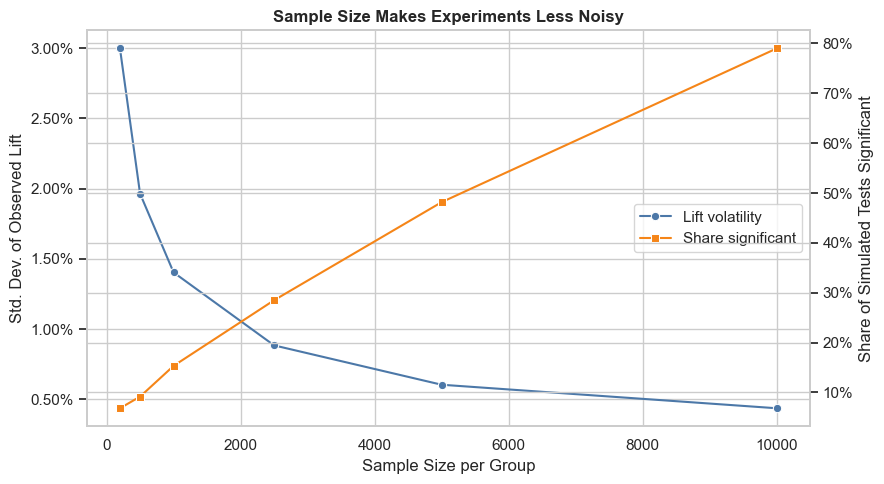

In [13]:
size_df = sample_size_sensitivity()
display(size_df)

fig, ax1 = plt.subplots(figsize=(9, 5))
sns.lineplot(data=size_df, x='n_per_group', y='lift_std', marker='o', color='#4C78A8', ax=ax1, label='Lift volatility')
ax1.set_xlabel('Sample Size per Group')
ax1.set_ylabel('Std. Dev. of Observed Lift')
ax1.yaxis.set_major_formatter(lambda x, pos: f'{x:.2%}')
ax2 = ax1.twinx()
sns.lineplot(data=size_df, x='n_per_group', y='share_significant', marker='s', color='#F58518', ax=ax2, label='Share significant')
ax2.set_ylabel('Share of Simulated Tests Significant')
ax2.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax1.set_title('Sample Size Makes Experiments Less Noisy')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
ax2.get_legend().remove()
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'sample_size_effect.png', dpi=160, bbox_inches='tight')
plt.show()

## 16. Lift and Business Impact

Statistical significance asks whether an effect is likely real.

Business significance asks whether it is worth acting on.

A tiny lift can matter at huge scale. A statistically real lift can still be too small to justify engineering cost. Experiments live at the intersection of statistics and judgment.

,monthly_users,absolute_lift,incremental_conversions,incremental_revenue
0,500000,0.017644,8822.033931,769218.137645


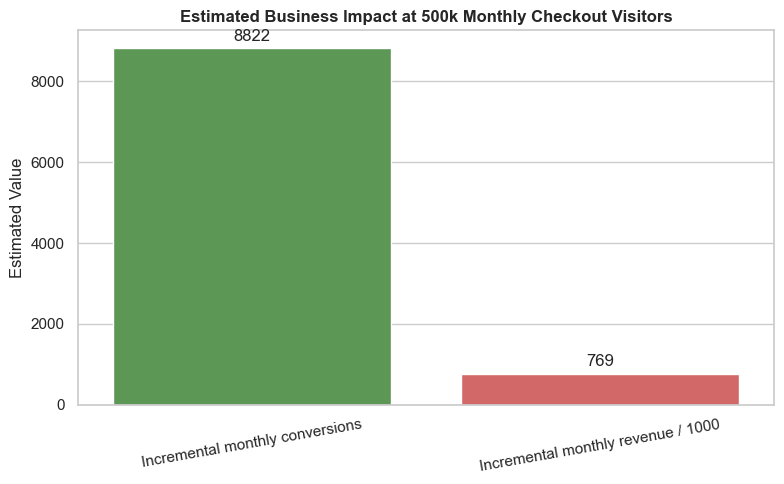

In [14]:
avg_order_value = df.loc[df['converted'] == 1, 'revenue'].mean()
impact = business_impact(control_rate, treatment_rate, monthly_users=500000, avg_order_value=avg_order_value)
display(pd.DataFrame([impact]))

fig, ax = plt.subplots(figsize=(8, 5))
impact_values = pd.DataFrame({
    'metric': ['Incremental monthly conversions', 'Incremental monthly revenue / 1000'],
    'value': [impact['incremental_conversions'], impact['incremental_revenue'] / 1000]
})
sns.barplot(data=impact_values, x='metric', y='value', palette=['#54A24B', '#E45756'], ax=ax)
ax.set_title('Estimated Business Impact at 500k Monthly Checkout Visitors')
ax.set_xlabel('')
ax.set_ylabel('Estimated Value')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'business_impact.png', dpi=160, bbox_inches='tight')
plt.show()

## 17. Practical Experimentation Pitfalls

Real experiments fail in quieter ways than formulas suggest.

Watch for:

- **Peeking bias:** stopping as soon as results look good.
- **Novelty effects:** users react to newness, not lasting value.
- **Seasonality:** weekends, holidays, campaigns, and paydays shift behavior.
- **Selection bias:** treatment and control receive different kinds of users.
- **Multiple testing:** many experiments increase the chance of false positives.
- **Tracking bugs:** instrumentation changes can masquerade as product changes.

A/B testing is powerful because it is controlled. When the control breaks, the trust breaks.

## 18. Simulating Randomness in Experiments

Now we run the same kind of experiment many times in simulation.

This shows why one result is never a prophecy. It is a measurement with uncertainty.

,experiment,control_rate,treatment_rate,observed_lift,p_value,significant_05
0,1,0.1140,0.1312,0.0172,0.063721,False
1,2,0.1092,0.1276,0.0184,0.044057,True
2,3,0.1160,0.1328,0.0168,0.071907,False
3,4,0.1100,0.1140,0.0040,0.653839,False
4,5,0.1128,0.1292,0.0164,0.075417,False


Average observed lift: 1.748%
Share significant at 0.05: 46.9%


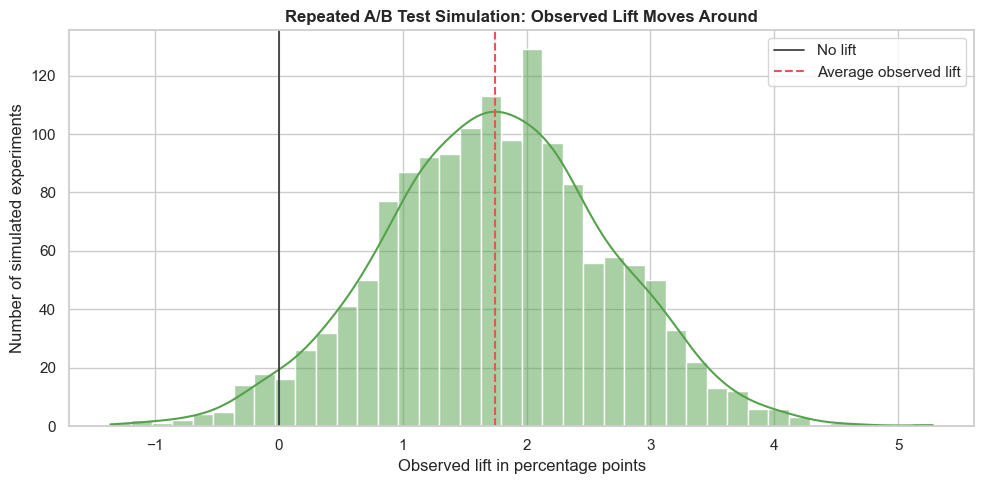

In [15]:
sim_df = simulate_repeated_experiments(n_experiments=1500, n_per_group=2500, p_control=control_rate, p_treatment=treatment_rate, seed=99)
display(sim_df.head())
print(f"Average observed lift: {sim_df['observed_lift'].mean():.3%}")
print(f"Share significant at 0.05: {sim_df['significant_05'].mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(sim_df['observed_lift'] * 100, bins=40, kde=True, color='#54A24B', ax=ax)
ax.axvline(0, color='#333333', linewidth=1.2, label='No lift')
ax.axvline(sim_df['observed_lift'].mean() * 100, color='#E45756', linestyle='--', label='Average observed lift')
ax.set_title('Repeated A/B Test Simulation: Observed Lift Moves Around')
ax.set_xlabel('Observed lift in percentage points')
ax.set_ylabel('Number of simulated experiments')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'experiment_simulation.png', dpi=160, bbox_inches='tight')
plt.show()

## 19. Real-World Applications

A/B testing powers product learning at modern technology companies.

Teams use experiments for:

- checkout optimization
- landing page conversion
- email subject lines
- pricing pages
- onboarding flows
- recommendation systems
- search ranking changes
- ad click-through rates
- retention interventions

The common theme is not the metric. The common theme is disciplined learning.

## 20. Final Takeaway

A/B testing is not just statistics.

It is a way of making decisions when the future is uncertain.

GraphX Labs takeaway:

> Opinions can start the experiment. Evidence decides what earns the rollout.

## 21. Interview Questions

A detailed interview guide is available here:

```text
../interview_questions.md
```

Use it to connect the notebook intuition to practical data science interview answers.